## Oppgave 1: Punkt på kart (*5 poeng*)

I denne oppgaven fortsetter vi å lære hvordan vi kan lage geometriske former fra bredde- og lengdegrader.

**Målet vårt er å plotte et kart med punkter, basert på et sett med lengde- og breddegrader som er lagret i en csv-fil.**

Inputdataene er lagret i CSV-regnearket `some_posts.csv` i mappen `data`. Koordinatene som er lagret der er i WGS84-format (desimalgrader, EPSG:4326), og de første radene med data ser slik ut:

```
lat,lon,timestamp,userid
-24.980792492,31.484633302,2015-07-07 03:02,66487960
-25.499224667,31.508905612,2015-07-07 03:18,65281761
-24.342578456,30.930866066,2015-03-07 03:38,90916112
-24.85461393,31.519718439,2015-10-07 05:04,37959089
```

Dataene har 81379 rader og består av lokasjoner og tidspunkter for anonymiserte sosiale medieposter inne i Kruger nasjonalpark i Sør-Afrika:

| Kolonne | Beskrivelse |
|---------|-------------|
| lat | y-koordinat for posten |
| lon | x-koordinat for posten |
| timestamp | Tidspunkt når posten ble lastet opp |
| userid | unik id for hver bruker|

*Merk: Selv om dataene er basert på ekte sosiale mediedata, har bruker-IDer og tidsstempler blitt randomisert, noe som gjør det umulig å knytte dataene til de opprinnelige innleggene.*

In [1]:
# Imports
import pathlib
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString

### a) Les CSV-filen

- Les dataene fra `some_posts.csv` inn i en Pandas dataframe kalt `data`

In [2]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_MAPPE = NOTEBOOK_PATH / "data"

data = pd.read_csv(DATA_MAPPE / "some_posts.csv")
data.head()

,lat,lon,timestamp,userid
0,-24.980792,31.484633,2015-07-07 03:02,66487960
1,-25.499225,31.508906,2015-07-07 03:18,65281761
2,-24.342578,30.930866,2015-03-07 03:38,90916112
3,-24.854614,31.519718,2015-10-07 05:04,37959089
4,-24.921069,31.520836,2015-10-07 05:19,27793716


In [3]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### b) Legg til en geometri-kolonne og fyll den med geometriske objekter

- Opprett en tom kolonne kalt `geometry` hvor du vil lagre shapely Point-objekter
- Sett inn Point-objekter i kolonnen `geometry` basert på koordinatkolonnene

Du skal opprette et `shapely.geometry.Point` *for hver rad*, basert på kolonnene `lon` og `lat`.
Det finnes forskjellige tilnærminger til denne oppgaven, du oppfordres til å prøve å bruke [`apply()`-metoden](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html) til dataframen, sammen med en *lambda-funksjon* (se [**hintene for denne oppgaven**](https://haavardaagesen.github.io/gmgi221/content/pages/03_oving-3.html))

In [4]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

data["geometry"] = data.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
data.head()

,lat,lon,timestamp,userid,geometry
0,-24.980792,31.484633,2015-07-07 03:02,66487960,POINT (31.484633302 -24.980792492)
1,-25.499225,31.508906,2015-07-07 03:18,65281761,POINT (31.508905612 -25.499224667)
2,-24.342578,30.930866,2015-03-07 03:38,90916112,POINT (30.930866066 -24.342578456)
3,-24.854614,31.519718,2015-10-07 05:04,37959089,POINT (31.519718439 -24.85461393)
4,-24.921069,31.520836,2015-10-07 05:19,27793716,POINT (31.520835558 -24.921068894)


In [5]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### c) Konverter `pandas.DataFrame` til en `geopandas.GeoDataFrame`

- Konverter `data` til en `geopandas.GeoDataFrame` ved å bruke dens [konstruktør](https://geopandas.org/reference/geopandas.GeoDataFrame.html). (*Se [**hintene for denne oppgaven**](https://haavardaagesen.github.io/gmgi221/content/pages/03_oving-3.html) for ytterligere instruksjoner*)
- Sørg for at den resulterende `GeoDataFrame` har et definert koordinatsystem

In [6]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

gdf = gpd.GeoDataFrame(data, geometry="geometry", crs="EPSG:4326")
gdf.head()

,lat,lon,timestamp,userid,geometry
0,-24.980792,31.484633,2015-07-07 03:02,66487960,POINT (31.48463 -24.98079)
1,-25.499225,31.508906,2015-07-07 03:18,65281761,POINT (31.50891 -25.49922)
2,-24.342578,30.930866,2015-03-07 03:38,90916112,POINT (30.93087 -24.34258)
3,-24.854614,31.519718,2015-10-07 05:04,37959089,POINT (31.51972 -24.85461)
4,-24.921069,31.520836,2015-10-07 05:19,27793716,POINT (31.52084 -24.92107)


In [7]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### d) Lagre dataene i Shapefile-format som `kruger_points.shp` i `data`-katalogen

In [8]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

gdf.to_file(DATA_MAPPE / "kruger_points.shp")

In [9]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### e) Lag et enkelt kart som viser punktene

<Axes: >

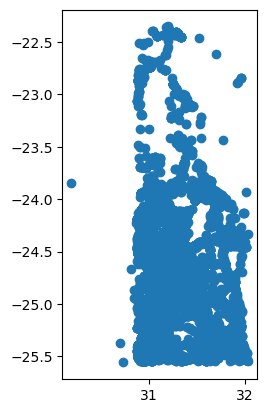

In [10]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

gdf.plot()

## Oppgave 2: Hvor langt har brukerne reist? (*5 poeng*)

I denne oppgaven er målet å beregne (luftlinje)avstanden i meter som hver sosiale mediebruker i datasettet utarbeidet i *Oppgave 1* har reist mellom innleggene. Vi er interessert i den euklidiske avstanden mellom påfølgende punkter generert av samme bruker.

For dette trenger vi å bruke `userid`-kolonnen i datasettet `kruger_posts.shp` som vi opprettet i *Oppgave 1*.

Svar på følgende spørsmål:
- Hva var den korteste avstanden en bruker reiste mellom alle sine poster (i meter)?
- Hva var gjennomsnittsavstanden reist per bruker (i meter)?
- Hva var den maksimale avstanden en bruker reiste (i meter)?

### a) Les inputfilen og re-projiser den

- Les inputfilen `kruger_points.shp` inn i en geo-dataframe med navn `kruger_points`
- Transformer dataene fra WGS84 til en `EPSG:32735`-projeksjon (UTM sone 35S, egnet for Sør-Afrika). Dette koordinatsystemet har *meter* som enheter.

In [11]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

kruger_points = gpd.read_file(DATA_MAPPE / "kruger_points.shp")
kruger_points.to_crs(epsg=32735, inplace=True)

In [12]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### b) Grupper dataene etter bruker-ID

Grupper dataene etter `userid` og lagre de grupperte dataene i en variabel `grouped_by_users`

In [13]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

grouped_by_users = kruger_points.groupby("userid")
print(grouped_by_users.groups)

{16301: [30512, 30535, 30545, 30770, 38232, 38235, 38909, 38911, 38913], 26589: [61781], 29322: [78280], 42181: [8081], 45136: [80613, 81278], 48971: [71512], 50136: [42402, 42439, 42453, 42478, 42526, 42566, 42620, 42670, 42751, 42880], 50530: [79157], 66129: [60285], 74329: [4003], 75914: [60235], 76069: [2388], 88775: [15288, 15289], 88918: [37496, 37879], 90156: [74848, 74852, 75080, 75081, 75083, 75085, 75089, 75091], 120615: [81361], 133296: [66934], 141256: [47421], 156058: [4775], 161653: [59189], 174181: [35734, 35735], 177106: [47034], 177600: [7616, 9609, 9610, 9611, 9678, 9679], 180146: [70740], 181216: [52587, 52688, 52779, 52838, 52965], 184404: [4006, 4203, 4974, 74796, 76816], 186335: [47691], 193414: [78179, 78912, 79513], 195149: [56739, 56771, 56775, 56777, 56779], 198845: [51067, 51726], 209862: [75654], 214933: [10933, 10935], 217091: [72658, 73097, 73099], 222264: [36677, 48629, 48631], 228231: [16713], 231302: [13437], 232626: [3610, 3611, 3612, 3613, 3614, 3615,

In [14]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### c) Opprett `shapely.geometry.LineString`-objekter for hver bruker som kobler punktene fra eldste til nyeste

Det finnes flere måter å løse dette problemet på (se [**hintene for denne oppgaven**](https://haavardaagesen.github.io/gmgi221/content/pages/03_oving-3.html)). Du kan for eksempel bruke en ordbok (dictionary) eller en tom GeoDataFrame for å samle data som genereres ved å bruke trinnene nedenfor:

- Bruk en for-løkke for å iterere over det grupperte objektet. For hver brukers data:
    - [sorter](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.sort_values.html) radene etter tidsstempel
    - opprett en `shapely.geometry.LineString` basert på brukerens punkter

**OBS**: Husk at hver LineString trenger minst to punkter. Hopp over brukere som har mindre enn to poster.

Lagre resultatene i en `geopandas.GeoDataFrame` kalt `movements`, og husk å tildele et koordinatsystem (CRS).

In [15]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

dict = {
    "userid": [],
    "geometry" : []
}

for userid, group in grouped_by_users:
    groups_sorted = group.sort_values("timestamp")

    coords = [point.coords[0] for point in groups_sorted["geometry"]]

    if len(coords) >= 2:
        dict["userid"].append(userid)
        dict["geometry"].append(LineString(coords))

movements = gpd.GeoDataFrame(dict, crs="EPSG:32735")

movements.head()

,userid,geometry
0,16301,"LINESTRING (942231.63 7254606.868, 938934.725 ..."
1,45136,"LINESTRING (905394.5 7193375.148, 905394.5 719..."
2,50136,"LINESTRING (944551.607 7253384.183, 963788.403..."
3,88775,"LINESTRING (902800.817 7192546.975, 902800.839..."
4,88918,"LINESTRING (959332.961 7219877.715, 963788.403..."


In [16]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### d) Beregn avstanden mellom alle postene til en bruker

- Sjekk en gang til at koordinatsystemet (CRS) til dataframen er korrekt
- Beregn lengdene av linjene, og lagre det i en ny kolonne kalt `distance`

In [17]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

movements.crs

<Projected CRS: EPSG:32735>
Name: WGS 84 / UTM zone 35S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 24°E and 30°E, southern hemisphere between 80°S and equator, onshore and offshore. Botswana. Burundi. Democratic Republic of the Congo (Zaire). Rwanda. South Africa. Tanzania. Uganda. Zambia. Zimbabwe.
- bounds: (24.0, -80.0, 30.0, 0.0)
Coordinate Operation:
- name: UTM zone 35S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [18]:
movements["distance"] = movements.length
movements.head()

,userid,geometry,distance
0,16301,"LINESTRING (942231.63 7254606.868, 938934.725 ...",328455.115430
1,45136,"LINESTRING (905394.5 7193375.148, 905394.5 719...",0.000000
2,50136,"LINESTRING (944551.607 7253384.183, 963788.403...",159189.081019
3,88775,"LINESTRING (902800.817 7192546.975, 902800.839...",0.080245
4,88918,"LINESTRING (959332.961 7219877.715, 963788.403...",9277.252211


In [19]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### e) Svar på de opprinnelige spørsmålene

Du bør nå raskt kunne finne svar på følgende spørsmål:
- Hva var den korteste avstanden en bruker reiste mellom alle sine poster (i meter)? (lagre verdien i en variabel `shortest_distance`)
- Hva var gjennomsnittsavstanden reist per bruker (i meter)? (lagre verdien i en variabel `mean_distance`)
- Hva var den maksimale avstanden en bruker reiste (i meter)? (lagre verdien i en variabel `longest_distance`)

In [20]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

shortest_distance = movements["distance"].min()
print(f"Den korteste avstanden er {shortest_distance} m.")

mean_distance = movements["distance"].mean()
print(f"Den gjennomsnittlige avstanden er {mean_distance:.4f} m.")

longest_distance = movements["distance"].max()
print(f"Den maksimale avstanden er {longest_distance} m.")

Den korteste avstanden er 0.0 m.
Den gjennomsnittlige avstanden er 107133.5120 m.
Den maksimale avstanden er 6970668.816343971 m.


In [21]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

### f) Lagre bevegelsene i en fil

Lagre `movements` i en ny Shapefil kalt `movements.shp` i `data`-mappen.

In [22]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

movements.to_file(DATA_MAPPE / "movements.shp")

In [23]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

## Supert! Du er nå ferdig med øving 3!